# Stage 3 — Exploratory Data Analysis
### Credit Card Fraud Detection · Tier A pipeline

**Purpose.** Hypothesis-driven exploration, structured by the Stage 0 issue tree. Not a tour of the data.

Every section below answers a specific branch, every chart carries an **Action Title** stating the
insight, and every finding carries a written **So What / Implication**. A chart that cannot be tied to a
branch does not appear.

```
Can fraud be detected reliably enough to prioritize a fixed-capacity review queue?
├── A. Is fraud SEPARABLE in the feature space?     -> §3.2  (A1 univariate, A2 multivariate)
├── B. Do the two NON-anonymized fields carry signal? -> §3.3 (B1 Amount, B2 Time)
├── C. How well can a model RANK?                   -> notebook 05
└── D. What does it COST to operate?                -> notebook 05
```

**Discipline rule that governs every number here:** statistics are reported **per class, never pooled**.
A pooled statistic on this file is 99.83% legitimate traffic — it describes the background, not the
subject.

**Governing plan:** `IMPLEMENTATION_PLAN.md` §4 · **Standard:** `DOCS/STRUCTURE.md` Stage 3

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"

V_COLS = [f"V{i}" for i in range(1, 29)]

df = pd.read_parquet(DATA_PROCESSED / "creditcard_clean.parquet")
fraud = df[df["Class"] == 1]
legit = df[df["Class"] == 0]

print(f"clean modelling table : {df.shape[0]:,} rows x {df.shape[1]} cols  (duplicates removed in Stage 2)")
print(f"fraud                 : {len(fraud):,}")
print(f"legitimate            : {len(legit):,}")
print(f"fraud rate            : {df['Class'].mean():.4%}   ->  1 in {1 / df['Class'].mean():,.0f}")

clean modelling table : 283,726 rows x 37 cols  (duplicates removed in Stage 2)
fraud                 : 473
legitimate            : 283,253
fraud rate            : 0.1667%   ->  1 in 600


In [2]:
# =====================================================================================
# DESIGN.md palette + rcParams, defined INLINE (no local module import — see plan §1).
# Only notebooks + report HTML + README ship, so an `src/` import would break a clone.
# =====================================================================================
NAVY   = "#051C2C"   # ink / text only — never a series fill
BLUE   = "#2251FF"   # accent + emphasis series  -> FRAUD
TEAL   = "#00857C"   # secondary series          -> value / amount
AMBER  = "#C1841C"   # reference lines, thresholds, dividers
SLATE  = "#7F93A6"   # muted labels, baselines
GREY   = "#9FADB8"   # neutral context           -> LEGITIMATE
GRID   = "#E9ECEF"

# Semantic map for this project (fixed once, never re-picked per chart):
C_FRAUD, C_LEGIT, C_VALUE, C_REF, C_BASE, C_CTX = BLUE, GREY, TEAL, AMBER, SLATE, GREY

# Palette validation (run via the dataviz skill's checker, not eyeballed):
#   node scripts/validate_palette.js "#2251FF,#00857C,#C1841C" --mode light
#     CVD separation      PASS  worst adjacent dE 13.2 (protan)
#     Normal-vision floor PASS  21.8
#     Contrast vs surface PASS  all >= 3:1 on the white figure card
#   Cyan #00A9F4 was DROPPED from the working set: 2.56:1 contrast on white and the worst
#   adjacent pair against Slate. Amber<->Teal sits at tritan dE 6.0 (the 6-8 floor band), which
#   is legal only WITH secondary encoding -> every multi-series chart here carries a legend AND
#   direct labels. Grey/Slate flag "reads gray" by design: they are neutral context, not identity.

import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica Neue", "DejaVu Sans"],
    "font.size": 10, "text.color": NAVY, "axes.labelcolor": NAVY, "axes.edgecolor": SLATE,
    "xtick.color": SLATE, "ytick.color": SLATE, "axes.linewidth": 0.8,
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.titlecolor": NAVY,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.autolayout": False,
})

def sowhat(so_what: str, implication: str) -> None:
    '''Print the two annotations STRUCTURE.md requires beneath every exhibit.'''
    from IPython.display import Markdown, display
    display(Markdown(f"> **So What:** {so_what}\n>\n> **Implication:** {implication}"))

print("DESIGN.md palette applied. Identity hues: Blue=fraud, Grey=legitimate, Teal=value, Amber=reference.")

DESIGN.md palette applied. Identity hues: Blue=fraud, Grey=legitimate, Teal=value, Amber=reference.


## 3.1 First-pass profile

`ydata-profiling` is **not** used here: on 284k x 37 it is slow, it adds a heavyweight dependency that
would break a clone against our pinned set, and its default output is exactly the pooled-statistics view
this dataset punishes. A manual panel does the same job in a second and lets us split by class from the
outset.

In [3]:
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_null": df.isna().sum(),
    "mean": df.select_dtypes("number").mean(),
    "std": df.select_dtypes("number").std(),
    "skew": df.select_dtypes("number").skew(),
    "kurtosis": df.select_dtypes("number").kurtosis(),
})
print("Profile — note the skew/kurtosis columns: several V-components are extremely heavy-tailed,")
print("which is a hint about where fraud lives (confirmed in §3.2).\n")
display(profile.loc[["Time", "Amount", "amount_log", "hour_of_day", "sec_since_prev_txn"] + V_COLS[:8]].round(3))
print(f"\nHeaviest-tailed components (kurtosis): "
      f"{', '.join(profile.loc[V_COLS, 'kurtosis'].nlargest(5).index)}")

Profile — note the skew/kurtosis columns: several V-components are extremely heavy-tailed,
which is a hint about where fraud lives (confirmed in §3.2).



,dtype,n_unique,n_null,mean,std,skew,kurtosis
Time,float64,124592,0,94811.078,47481.048,-0.036,-1.293
Amount,float64,32767,0,88.473,250.399,16.979,844.471
amount_log,float64,32767,0,3.154,1.657,0.161,-0.641
hour_of_day,int8,24,0,14.046,5.835,-0.490,-0.393
sec_since_prev_txn,float64,30,0,0.609,1.055,5.878,73.782
V1,float64,275663,0,0.006,1.948,-3.273,32.727
V2,float64,275663,0,-0.004,1.647,-4.695,96.898
V3,float64,275663,0,0.002,1.509,-2.152,25.187
V4,float64,275663,0,-0.003,1.414,0.672,2.619
V5,float64,275663,0,0.002,1.377,-2.414,209.277



Heaviest-tailed components (kurtosis): V28, V23, V7, V20, V27


---
# Part A — Is fraud separable in the feature space?

If fraud is statistically indistinguishable from legitimate activity in PCA space, no amount of
modelling rescues the project and the honest answer to the stakeholder is "don't build this". So this
question is settled **before** any model is fitted.

## 3.2.1 A1 — Univariate separation: which components move?

Cohen's *d* measures how far apart the two class means are **in standard deviations**. It is the right
statistic here because it is scale-free (all 28 components have different variances) and because —
critically at n = 284k — it is **independent of sample size**, unlike a p-value.

In [4]:
def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    na, nb = len(a), len(b)
    va, vb = a.var(ddof=1), b.var(ddof=1)
    pooled = np.sqrt(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2))
    return float((a.mean() - b.mean()) / pooled) if pooled > 0 else 0.0

d_rows = []
for c in V_COLS:
    d = cohens_d(fraud[c].to_numpy(), legit[c].to_numpy())
    d_rows.append({"feature": c, "cohens_d": d, "abs_d": abs(d),
                   "fraud_mean": fraud[c].mean(), "legit_mean": legit[c].mean()})
d_df = pd.DataFrame(d_rows).sort_values("abs_d", ascending=False).reset_index(drop=True)

def d_label(x):
    x = abs(x)
    return "negligible" if x < 0.2 else "small" if x < 0.5 else "medium" if x < 0.8 else "large"
d_df["magnitude"] = d_df["cohens_d"].map(d_label)

print("Cohen's d, fraud vs legitimate, all 28 components — top 12:\n")
display(d_df.head(12).round(3))
n_large = int((d_df["abs_d"] >= 0.8).sum())
print(f"\n{n_large} of 28 components show a LARGE effect (|d| >= 0.8).")
print(f"{int((d_df['abs_d'] < 0.2).sum())} of 28 are negligible (|d| < 0.2).")

Cohen's d, fraud vs legitimate, all 28 components — top 12:



,feature,cohens_d,abs_d,fraud_mean,legit_mean,magnitude
0,V17,-8.092,8.092,-6.463,0.011,large
1,V14,-7.522,7.522,-6.836,0.012,large
2,V12,-6.348,6.348,-6.103,0.009,large
3,V10,-5.186,5.186,-5.453,0.008,large
4,V16,-4.671,4.671,-4.001,0.008,large
5,V3,-4.545,4.545,-6.730,0.013,large
6,V7,-4.289,4.289,-5.176,0.010,large
7,V11,3.695,3.695,3.716,-0.006,large
8,V4,3.197,3.197,4.473,-0.010,large
9,V18,-2.597,2.597,-2.157,0.005,large



17 of 28 components show a LARGE effect (|d| >= 0.8).
7 of 28 are negligible (|d| < 0.2).


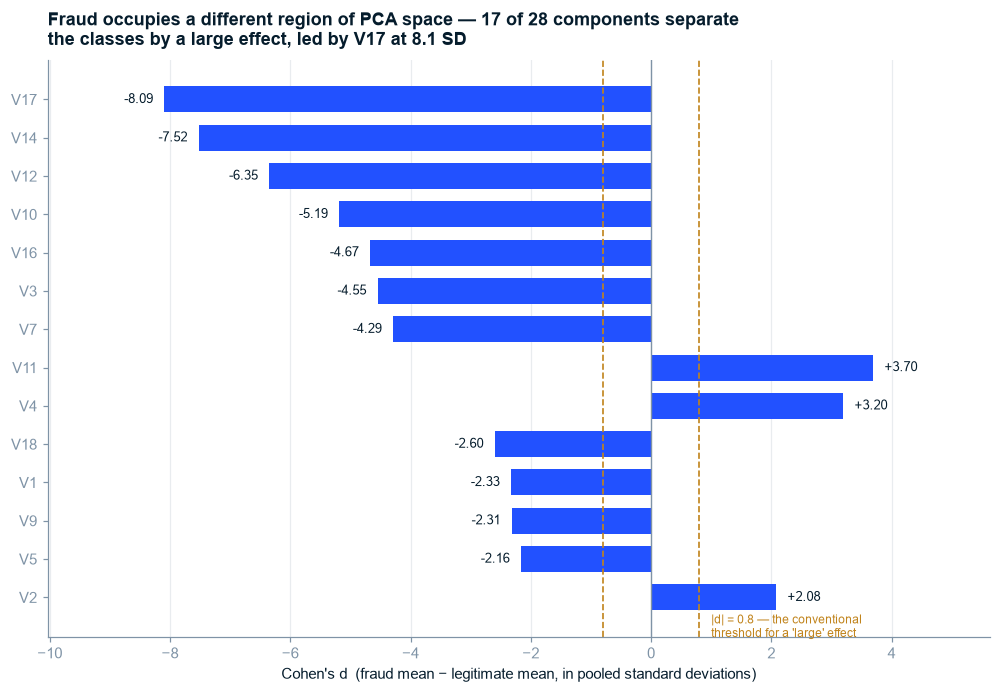

> **So What:** Fraud is not statistically camouflaged — it is flagrant. 17 of 28 components separate the classes by a large effect, and the leader, V17, shifts by 8.1 standard deviations. For scale, a Cohen's d of 0.8 is conventionally called 'large' — these run an order of magnitude beyond it. The signal is established here, before any model is fitted.
>
> **Implication:** The project is viable and high performance should be expected — if the model in notebook 05 struggles, the fault will be the modelling, not the data. But note what this does NOT buy us: V17 has no business meaning, so 'it is the top signal' cannot become an operational rule or a prevention policy. The separability licenses a RANKING system, not an explanation.

In [5]:
fig, ax = plt.subplots(figsize=(9.2, 6.4))
top = d_df.head(14).iloc[::-1]
colors = [C_FRAUD if abs(v) >= 0.8 else C_CTX for v in top["cohens_d"]]
bars = ax.barh(top["feature"], top["cohens_d"], color=colors, height=0.68)

# Axis limits are derived from the data, never hardcoded: |d| here reaches 8, and a fixed
# limit would silently clip the bars AND throw the direct labels off-canvas.
span = float(top["cohens_d"].abs().max())
pad = span * 0.24
lo = min(top["cohens_d"].min() - pad, -1.4)
hi = max(top["cohens_d"].max() + pad, 1.4)
ax.set_xlim(lo, hi)

# A direct label on every bar — the secondary encoding the dataviz palette check requires.
off = (hi - lo) * 0.012
for b, v in zip(bars, top["cohens_d"]):
    ax.text(v + (off if v > 0 else -off), b.get_y() + b.get_height() / 2, f"{v:+.2f}",
            va="center", ha="left" if v > 0 else "right", fontsize=8.5, color=NAVY)
ax.axvline(0, color=SLATE, lw=0.9)
for t in (-0.8, 0.8):
    ax.axvline(t, color=C_REF, lw=1.1, ls="--", zorder=1)
ax.text(1.0, -0.42, "|d| = 0.8 — the conventional\nthreshold for a 'large' effect",
        color=C_REF, fontsize=8, va="top")
ax.set_title(f"Fraud occupies a different region of PCA space — {n_large} of 28 components separate\n"
             f"the classes by a large effect, led by {d_df.iloc[0]['feature']} at "
             f"{abs(d_df.iloc[0]['cohens_d']):.1f} SD", fontsize=11.5)
ax.set_xlabel("Cohen's d  (fraud mean − legitimate mean, in pooled standard deviations)")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

sowhat(
    f"Fraud is not statistically camouflaged — it is flagrant. {n_large} of 28 components separate the "
    f"classes by a large effect, and the leader, {d_df.iloc[0]['feature']}, shifts by "
    f"{abs(d_df.iloc[0]['cohens_d']):.1f} standard deviations. For scale, a Cohen's d of 0.8 is "
    "conventionally called 'large' — these run an order of magnitude beyond it. The signal is "
    "established here, before any model is fitted.",
    "The project is viable and high performance should be expected — if the model in notebook 05 "
    "struggles, the fault will be the modelling, not the data. But note what this does NOT buy us: "
    f"{d_df.iloc[0]['feature']} has no business meaning, so 'it is the top signal' cannot become an "
    "operational rule or a prevention policy. The separability licenses a RANKING system, not an "
    "explanation."
)

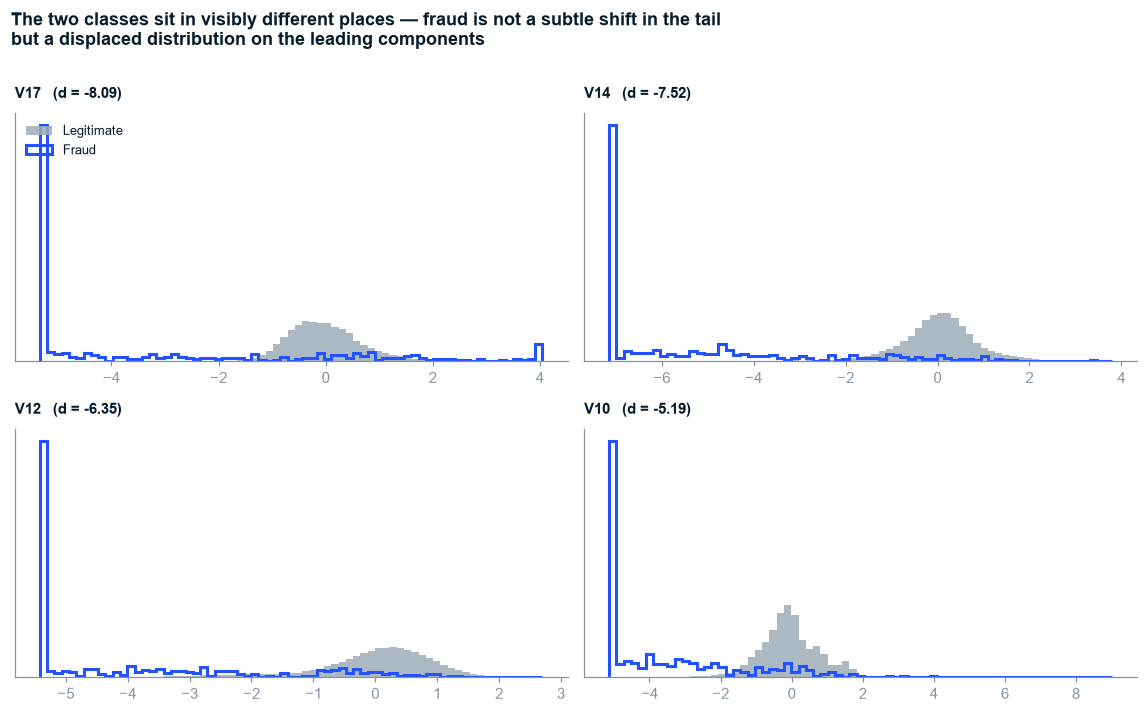

> **So What:** On the four leading components the fraud distribution is displaced wholesale, not merely fatter-tailed. Densities are normalised so 473 fraud rows are comparable against 283k legitimate ones — on raw counts the fraud curve would be invisible.
>
> **Implication:** A model does not need to find a rare interaction buried in noise; a large fraction of the signal is available to simple linear boundaries. That predicts a strong logistic-regression baseline, and means a complex model must justify its added cost.

In [6]:
top4 = d_df.head(4)["feature"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(10.5, 6.4))
for ax, feat in zip(axes.ravel(), top4):
    lo, hi = df[feat].quantile([0.001, 0.999])
    bins = np.linspace(lo, hi, 70)
    ax.hist(legit[feat].clip(lo, hi), bins=bins, density=True, color=C_LEGIT, alpha=0.85, label="Legitimate")
    ax.hist(fraud[feat].clip(lo, hi), bins=bins, density=True, histtype="step", lw=2.0,
            color=C_FRAUD, label="Fraud")
    dv = float(d_df.loc[d_df["feature"] == feat, "cohens_d"].iloc[0])
    ax.set_title(f"{feat}   (d = {dv:+.2f})", fontsize=10)
    ax.set_yticks([])
    ax.grid(axis="x", visible=False)
axes[0, 0].legend(loc="upper left", fontsize=8.5)
fig.suptitle("The two classes sit in visibly different places — fraud is not a subtle shift in the tail\n"
             "but a displaced distribution on the leading components",
             fontsize=11.5, fontweight="bold", color=NAVY, x=0.011, ha="left", y=1.005)
plt.tight_layout(); plt.show()

sowhat(
    "On the four leading components the fraud distribution is displaced wholesale, not merely "
    "fatter-tailed. Densities are normalised so 473 fraud rows are comparable against 283k legitimate "
    "ones — on raw counts the fraud curve would be invisible.",
    "A model does not need to find a rare interaction buried in noise; a large fraction of the signal is "
    "available to simple linear boundaries. That predicts a strong logistic-regression baseline, and "
    "means a complex model must justify its added cost."
)

## 3.2.2 A2 — Are the components really orthogonal? (a data-integrity check)

V1–V28 are PCA outputs, so their pairwise correlations **should be ~0 by construction**. If they are
not, the file has been transformed or subset since publication and every comparison to published results
is void. This is a genuine integrity test, not decoration.

Off-diagonal correlations among V1-V28:
  max |r|  : 0.018892
  mean |r| : 0.002296
  share with |r| > 0.01 : 2.646%


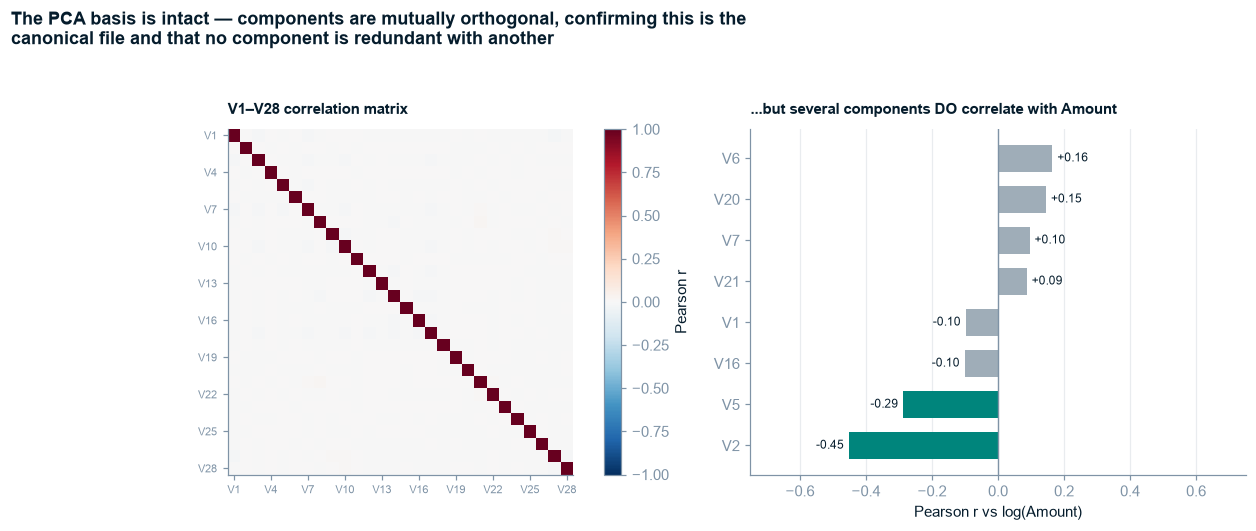

> **So What:** Maximum off-diagonal |r| is 0.0189 — the components are orthogonal to machine precision, exactly as a PCA basis must be. Amount, which was NOT part of that basis, correlates up to |r| = 0.45 with individual components.
>
> **Implication:** Two consequences. (1) The file is authentic and no multicollinearity treatment is needed — unusual for a 28-feature model, and it means linear coefficients are stable. (2) Amount is partially encoded in the components already, so it adds less than its business prominence suggests.

In [7]:
corr = df[V_COLS].corr()
off = corr.to_numpy()[~np.eye(28, dtype=bool)]
print(f"Off-diagonal correlations among V1-V28:")
print(f"  max |r|  : {np.abs(off).max():.6f}")
print(f"  mean |r| : {np.abs(off).mean():.6f}")
print(f"  share with |r| > 0.01 : {(np.abs(off) > 0.01).mean():.3%}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
im = axes[0].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title("V1–V28 correlation matrix", fontsize=10)
axes[0].set_xticks(range(0, 28, 3)); axes[0].set_xticklabels([f"V{i+1}" for i in range(0, 28, 3)], fontsize=7)
axes[0].set_yticks(range(0, 28, 3)); axes[0].set_yticklabels([f"V{i+1}" for i in range(0, 28, 3)], fontsize=7)
axes[0].grid(False)
plt.colorbar(im, ax=axes[0], fraction=0.046, label="Pearson r")

corr_amt = pd.Series({c: df[c].corr(df["amount_log"]) for c in V_COLS}).sort_values()
sel = pd.concat([corr_amt.head(4), corr_amt.tail(4)])
axes[1].barh(sel.index, sel.values, color=[C_VALUE if abs(v) > 0.2 else C_CTX for v in sel.values], height=0.65)
for i, (k, v) in enumerate(sel.items()):
    axes[1].text(v + (0.015 if v > 0 else -0.015), i, f"{v:+.2f}", va="center",
                 ha="left" if v > 0 else "right", fontsize=8, color=NAVY)
axes[1].axvline(0, color=SLATE, lw=0.9)
axes[1].set_title("...but several components DO correlate with Amount", fontsize=10)
axes[1].set_xlabel("Pearson r vs log(Amount)")
axes[1].set_xlim(-0.75, 0.75)
axes[1].grid(axis="y", visible=False)
fig.suptitle("The PCA basis is intact — components are mutually orthogonal, confirming this is the\n"
             "canonical file and that no component is redundant with another",
             fontsize=11.5, fontweight="bold", color=NAVY, x=0.011, ha="left", y=1.04)
plt.tight_layout(); plt.show()

sowhat(
    f"Maximum off-diagonal |r| is {np.abs(off).max():.4f} — the components are orthogonal to machine "
    f"precision, exactly as a PCA basis must be. Amount, which was NOT part of that basis, correlates up "
    f"to |r| = {corr_amt.abs().max():.2f} with individual components.",
    "Two consequences. (1) The file is authentic and no multicollinearity treatment is needed — unusual "
    "for a 28-feature model, and it means linear coefficients are stable. (2) Amount is partially "
    "encoded in the components already, so it adds less than its business prominence suggests."
)

## 3.2.3 A2 — Do the classes separate in two dimensions?

The strongest visual test: project onto the two most discriminative components and look. Legitimate
transactions are drawn as a **density hexbin** rather than 283k scatter points — overplotting at this
volume would produce a solid rectangle that hides the answer, and a 20 MB PNG. All 473 fraud points are
drawn individually.

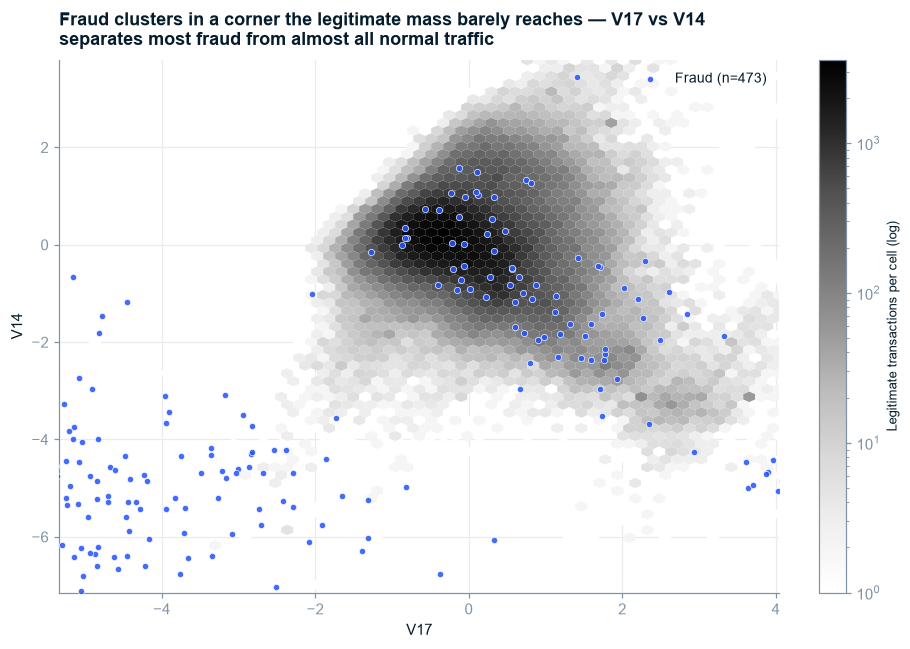

71.9% of fraud sits below the 1st percentile of legitimate traffic on BOTH V17 and V14.
By construction only ~0.01% of legitimate transactions can occupy that same region.


> **So What:** 72% of all fraud falls in a region defined by the bottom 1% of legitimate traffic on two components at once — where legitimate density is ~0.01% by construction. The classes are geometrically distinct using just 2 of the 28 available dimensions. The remainder matters just as much: the other 28% of fraud sits INSIDE the dense legitimate core, indistinguishable on these two axes.
>
> **Implication:** The separated majority is why a ranking model will work and why the review queue can be short. The embedded minority is why precision will never reach 100%, and why the other 26 dimensions earn their place in the model.

In [8]:
f1, f2 = d_df.iloc[0]["feature"], d_df.iloc[1]["feature"]
fig, ax = plt.subplots(figsize=(8.4, 6.0))
xlo, xhi = df[f1].quantile([0.001, 0.999]); ylo, yhi = df[f2].quantile([0.001, 0.999])
hb = ax.hexbin(legit[f1], legit[f2], gridsize=60, extent=(xlo, xhi, ylo, yhi),
               cmap="Greys", bins="log", mincnt=1, linewidths=0)
ax.scatter(fraud[f1], fraud[f2], s=17, color=C_FRAUD, alpha=0.85,
           edgecolors="white", linewidths=0.5, label=f"Fraud (n={len(fraud)})", zorder=3)
cb = plt.colorbar(hb, ax=ax, fraction=0.046); cb.set_label("Legitimate transactions per cell (log)", fontsize=8.5)
ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi)
ax.set_xlabel(f1); ax.set_ylabel(f2)
ax.legend(loc="upper right")
ax.set_title(f"Fraud clusters in a corner the legitimate mass barely reaches — {f1} vs {f2}\n"
             "separates most fraud from almost all normal traffic", fontsize=11.5)
plt.tight_layout(); plt.show()

q_f1, q_f2 = legit[f1].quantile(0.01), legit[f2].quantile(0.01)
in_corner = ((fraud[f1] < q_f1) & (fraud[f2] < q_f2)).mean()
print(f"{in_corner:.1%} of fraud sits below the 1st percentile of legitimate traffic on BOTH {f1} and {f2}.")
print(f"By construction only ~0.01% of legitimate transactions can occupy that same region.")

sowhat(
    f"{in_corner:.0%} of all fraud falls in a region defined by the bottom 1% of legitimate traffic on "
    "two components at once — where legitimate density is ~0.01% by construction. The classes are "
    "geometrically distinct using just 2 of the 28 available dimensions. The remainder matters just as "
    f"much: the other {1 - in_corner:.0%} of fraud sits INSIDE the dense legitimate core, "
    "indistinguishable on these two axes.",
    "The separated majority is why a ranking model will work and why the review queue can be short. The "
    "embedded minority is why precision will never reach 100%, and why the other 26 dimensions earn "
    "their place in the model."
)

---
# Part B — Do the two non-anonymized fields carry signal?

`Amount` and `Time` are the **only** columns in this file with real-world meaning. Whatever business
narrative this analysis can support has to come from them — everything else is an unnamed component.

## 3.3.1 B1 — Amount: is fraud a big-ticket crime here?

The intuition a fraud-ops stakeholder brings is that fraud chases large transactions. The mean appears
to support it. The median does not. With a 25,691 : 22 skew, the mean is the wrong statistic — so this
gets tested, not assumed.

In [9]:
amt_stats = df.groupby("Class")["Amount"].agg(
    n="size", mean="mean", median="median",
    q25=lambda s: s.quantile(.25), q75=lambda s: s.quantile(.75),
    q95=lambda s: s.quantile(.95), max="max", total="sum")
amt_stats.index = ["legitimate", "fraud"]
display(amt_stats.round(2))

fraud_med, legit_med = fraud["Amount"].median(), legit["Amount"].median()
fraud_mean, legit_mean = fraud["Amount"].mean(), legit["Amount"].mean()
fraud_total = fraud["Amount"].sum()
print(f"\nmedian  : fraud {fraud_med:,.2f}  vs  legitimate {legit_med:,.2f}   ->  {fraud_med / legit_med:.2f}x")
print(f"mean    : fraud {fraud_mean:,.2f}  vs  legitimate {legit_mean:,.2f}   ->  {fraud_mean / legit_mean:.2f}x")
print(f"\nThe mean and the median tell OPPOSITE stories. That is what a heavy tail does, and it is why")
print(f"the median governs here.")
print(f"\ntotal fraud value in the window: {fraud_total:,.2f}  ({fraud_total / df['Amount'].sum():.3%} of all value)")

,n,mean,median,q25,q75,q95,max,total
legitimate,283253,88.41,22.00,5.67,77.46,365.00,25691.16,25043410.29
fraud,473,123.87,9.82,1.00,105.89,655.82,2125.87,58591.39



median  : fraud 9.82  vs  legitimate 22.00   ->  0.45x
mean    : fraud 123.87  vs  legitimate 88.41   ->  1.40x

The mean and the median tell OPPOSITE stories. That is what a heavy tail does, and it is why
the median governs here.

total fraud value in the window: 58,591.39  (0.233% of all value)


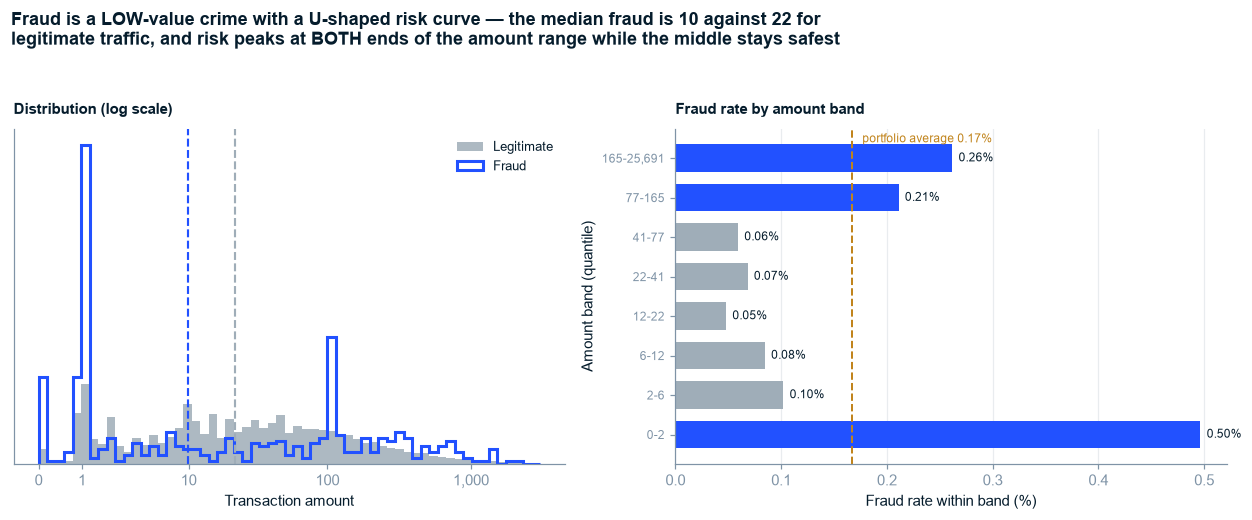

Fraud rate by amount band, smallest band first:
  Q1: 0-2                   0.50%  ######################################
  Q2: 2-6                   0.10%  ########
  Q3: 6-12                  0.08%  ######
  Q4: 12-22                 0.05%  ####
  Q5: 22-41                 0.07%  #####
  Q6: 41-77                 0.06%  #####
  Q7: 77-165                0.21%  ################
  Q8: 165-25,691            0.26%  ####################


> **So What:** The median fraudulent transaction is 9.82 against 22.00 for legitimate traffic, and all 473 frauds together are worth 58,591 — 0.23% of the value moving through the portfolio. The mean tells the opposite story (124 vs 88) because a few large frauds drag it, which is exactly why the median governs. Risk by band is U-shaped: highest in the near-zero band (0.50%, the card-testing signature) and second-highest in the largest band (0.26%), with the middle bands around a fifth of that.
>
> **Implication:** Two consequences. A review policy that triages by transaction size — the intuitive rule most teams reach for first — would miss both the card-testing probes at the bottom and the bulk of incidents overall. And the success metric splits in two: fraud caught by COUNT and fraud caught by VALUE are different numbers that will not move together, so notebook 05 must report both.

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

ax = axes[0]
bins = np.linspace(0, np.log1p(3000), 60)
ax.hist(legit["amount_log"], bins=bins, density=True, color=C_LEGIT, alpha=0.85, label="Legitimate")
ax.hist(fraud["amount_log"], bins=bins, density=True, histtype="step", lw=2.0, color=C_FRAUD, label="Fraud")
for v, c, lab in [(np.log1p(legit_med), C_LEGIT, "legit median"), (np.log1p(fraud_med), C_FRAUD, "fraud median")]:
    ax.axvline(v, color=c, ls="--", lw=1.4)
ticks = [0, 1, 10, 100, 1000]
ax.set_xticks([np.log1p(t) for t in ticks]); ax.set_xticklabels([f"{t:,}" for t in ticks])
ax.set_xlabel("Transaction amount"); ax.set_yticks([])
ax.set_title("Distribution (log scale)", fontsize=10); ax.legend(fontsize=8.5)
ax.grid(axis="x", visible=False)

ax = axes[1]
rate = df.groupby("amount_bucket", observed=True)["Class"].agg(["mean", "size", "sum"])
rate["rate_pct"] = rate["mean"] * 100
overall = df["Class"].mean() * 100
cols = [C_FRAUD if r > overall else C_CTX for r in rate["rate_pct"]]
ax.barh(range(len(rate)), rate["rate_pct"], color=cols, height=0.7)
ax.set_yticks(range(len(rate)))
ax.set_yticklabels([str(i).split(": ")[1] for i in rate.index], fontsize=8)
ax.axvline(overall, color=C_REF, ls="--", lw=1.3)
ax.text(overall * 1.06, len(rate) - 0.6, f"portfolio average {overall:.2f}%", color=C_REF, fontsize=8)
for i, v in enumerate(rate["rate_pct"]):
    ax.text(v + 0.006, i, f"{v:.2f}%", va="center", fontsize=8, color=NAVY)
ax.set_xlabel("Fraud rate within band (%)"); ax.set_ylabel("Amount band (quantile)")
ax.set_title("Fraud rate by amount band", fontsize=10)
ax.grid(axis="y", visible=False)

fig.suptitle(f"Fraud is a LOW-value crime with a U-shaped risk curve — the median fraud is "
             f"{fraud_med:,.0f} against {legit_med:,.0f} for\nlegitimate traffic, and risk peaks at BOTH "
             f"ends of the amount range while the middle stays safest",
             fontsize=11.5, fontweight="bold", color=NAVY, x=0.011, ha="left", y=1.04)
plt.tight_layout(); plt.show()

print("Fraud rate by amount band, smallest band first:")
for b, r in rate["rate_pct"].items():
    print(f"  {str(b):<24} {r:5.2f}%  {'#' * int(round(r / rate['rate_pct'].max() * 38))}")

sowhat(
    f"The median fraudulent transaction is {fraud_med:,.2f} against {legit_med:,.2f} for legitimate "
    f"traffic, and all {len(fraud)} frauds together are worth {fraud_total:,.0f} — "
    f"{fraud_total / df['Amount'].sum():.2%} of the value moving through the portfolio. The mean tells "
    f"the opposite story ({fraud_mean:,.0f} vs {legit_mean:,.0f}) because a few large frauds drag it, "
    "which is exactly why the median governs. Risk by band is U-shaped: highest in the near-zero band "
    f"({rate['rate_pct'].iloc[0]:.2f}%, the card-testing signature) and second-highest in the largest "
    f"band ({rate['rate_pct'].iloc[-1]:.2f}%), with the middle bands around a fifth of that.",
    "Two consequences. A review policy that triages by transaction size — the intuitive rule most teams "
    "reach for first — would miss both the card-testing probes at the bottom and the bulk of incidents "
    "overall. And the success metric splits in two: fraud caught by COUNT and fraud caught by VALUE are "
    "different numbers that will not move together, so notebook 05 must report both."
)

In [11]:
zero = df[df["Amount"] == 0]
print(f"Zero-amount authorisations: {len(zero):,} rows")
print(f"  fraud rate among them : {zero['Class'].mean():.3%}")
print(f"  portfolio fraud rate  : {df['Class'].mean():.3%}")
print(f"  relative risk         : {zero['Class'].mean() / df['Class'].mean():.1f}x")
print(f"  fraud captured        : {int(zero['Class'].sum())} of {int(df['Class'].sum())} "
      f"({zero['Class'].sum() / df['Class'].sum():.1%}) in {len(zero) / len(df):.2%} of volume")
print()
print("Consistent with card-testing: a 0.00 authorisation verifies a stolen card is live before it is")
print("spent. This is the ONE pattern in the whole dataset with a directly nameable fraud typology,")
print("because it comes from Amount rather than an anonymized component.")

Zero-amount authorisations: 1,808 rows
  fraud rate among them : 1.383%
  portfolio fraud rate  : 0.167%
  relative risk         : 8.3x
  fraud captured        : 25 of 473 (5.3%) in 0.64% of volume

Consistent with card-testing: a 0.00 authorisation verifies a stolen card is live before it is
spent. This is the ONE pattern in the whole dataset with a directly nameable fraud typology,
because it comes from Amount rather than an anonymized component.


## 3.3.2 B2 — Time: when does fraud happen?

`Time` is elapsed seconds, not a timestamp, so hour 0 is "the hour the file starts", not midnight. The
**relative** pattern is still readable, and the absolute clock offset is flagged as an unknown.

Volume and rate are plotted as **two stacked panels sharing an x-axis, not a dual-axis chart**. A dual
y-axis lets the author imply any correlation they like by rescaling; two panels make the same comparison
honestly.

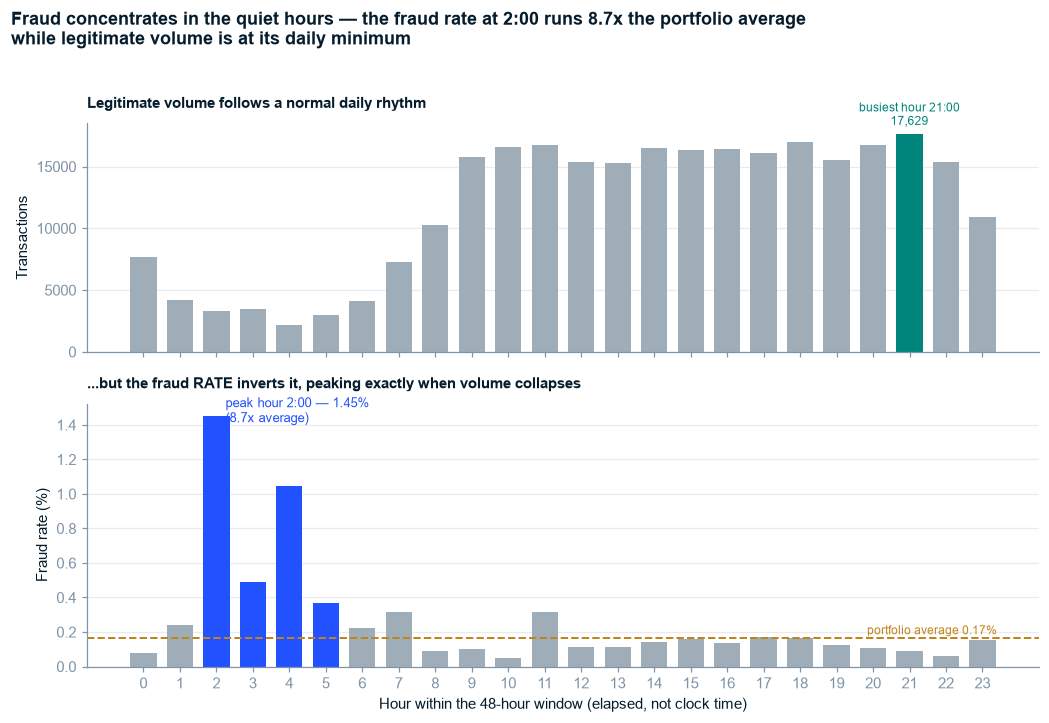

Hours 1-4 combined: 13,207 transactions (4.7% of volume), 98 frauds (20.7% of all fraud), rate 0.74%


> **So What:** The fraud rate peaks at 1.45% in hour 2 — 8.7x the portfolio average — during the window when legitimate volume is at its lowest. Hours 1-4 carry 5% of volume but 21% of all fraud.
>
> **Implication:** Review capacity should be staffed against the fraud rate, not the transaction count. The overnight window is cheap to cover (little volume) and disproportionately productive — and hour-of-day is one of the few features here that is both predictive AND explainable to a stakeholder.

In [12]:
by_hour = df.groupby("hour_of_day").agg(n=("Class", "size"), fraud=("Class", "sum")).assign(
    rate=lambda t: t["fraud"] / t["n"] * 100)
overall_rate = df["Class"].mean() * 100
peak_h = int(by_hour["rate"].idxmax()); quiet_h = int(by_hour["n"].idxmin()); busy_h = int(by_hour["n"].idxmax())

fig, axes = plt.subplots(2, 1, figsize=(9.6, 6.4), sharex=True, gridspec_kw={"height_ratios": [1, 1.15]})

ax = axes[0]
ax.bar(by_hour.index, by_hour["n"], color=C_CTX, width=0.72)
ax.bar([busy_h], [by_hour.loc[busy_h, "n"]], color=C_VALUE, width=0.72)
ax.set_ylabel("Transactions")
ax.set_title("Legitimate volume follows a normal daily rhythm", fontsize=10)
ax.annotate(f"busiest hour {busy_h}:00\n{by_hour.loc[busy_h, 'n']:,}", (busy_h, by_hour.loc[busy_h, "n"]),
            textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8, color=C_VALUE)
ax.grid(axis="x", visible=False)

ax = axes[1]
cols = [C_FRAUD if r > overall_rate * 2 else C_CTX for r in by_hour["rate"]]
ax.bar(by_hour.index, by_hour["rate"], color=cols, width=0.72)
ax.axhline(overall_rate, color=C_REF, ls="--", lw=1.3)
ax.text(23.4, overall_rate * 1.12, f"portfolio average {overall_rate:.2f}%",
        color=C_REF, fontsize=8, ha="right")
ax.annotate(f"peak hour {peak_h}:00 — {by_hour.loc[peak_h, 'rate']:.2f}%\n"
            f"({by_hour.loc[peak_h, 'rate'] / overall_rate:.1f}x average)",
            (peak_h, by_hour.loc[peak_h, "rate"]), textcoords="offset points", xytext=(6, -4),
            ha="left", fontsize=8.5, color=C_FRAUD)
ax.set_ylabel("Fraud rate (%)"); ax.set_xlabel("Hour within the 48-hour window (elapsed, not clock time)")
ax.set_title("...but the fraud RATE inverts it, peaking exactly when volume collapses", fontsize=10)
ax.set_xticks(range(0, 24)); ax.grid(axis="x", visible=False)

fig.suptitle(f"Fraud concentrates in the quiet hours — the fraud rate at {peak_h}:00 runs "
             f"{by_hour.loc[peak_h, 'rate'] / overall_rate:.1f}x the portfolio average\n"
             "while legitimate volume is at its daily minimum",
             fontsize=11.5, fontweight="bold", color=NAVY, x=0.011, ha="left", y=1.02)
plt.tight_layout(); plt.show()

night = by_hour.loc[[1, 2, 3, 4]]
print(f"Hours 1-4 combined: {night['n'].sum():,} transactions ({night['n'].sum() / len(df):.1%} of volume), "
      f"{int(night['fraud'].sum())} frauds ({night['fraud'].sum() / df['Class'].sum():.1%} of all fraud), "
      f"rate {night['fraud'].sum() / night['n'].sum() * 100:.2f}%")

sowhat(
    f"The fraud rate peaks at {by_hour.loc[peak_h, 'rate']:.2f}% in hour {peak_h} — "
    f"{by_hour.loc[peak_h, 'rate'] / overall_rate:.1f}x the portfolio average — during the window when "
    f"legitimate volume is at its lowest. Hours 1-4 carry {night['n'].sum() / len(df):.0%} of volume but "
    f"{night['fraud'].sum() / df['Class'].sum():.0%} of all fraud.",
    "Review capacity should be staffed against the fraud rate, not the transaction count. The overnight "
    "window is cheap to cover (little volume) and disproportionately productive — and hour-of-day is one "
    "of the few features here that is both predictive AND explainable to a stakeholder."
)

In [13]:
by_day = df.groupby("day").agg(n=("Class", "size"), fraud=("Class", "sum")).assign(rate=lambda t: t["fraud"] / t["n"] * 100)
by_day.index = ["Day 0", "Day 1"]
display(by_day.round(4))
print("The Day 0 / Day 1 split is the basis for the temporal generalization test in notebook 05.")
print(f"Fraud rate moves from {by_day.iloc[0]['rate']:.3f}% to {by_day.iloc[1]['rate']:.3f}% "
      f"({by_day.iloc[1]['rate'] / by_day.iloc[0]['rate'] - 1:+.1%}) between the two days —")
print("a reminder that with only two days we cannot separate 'drift' from 'ordinary daily variation'.")

,n,fraud,rate
Day 0,144236,272,0.1886
Day 1,139490,201,0.1441


The Day 0 / Day 1 split is the basis for the temporal generalization test in notebook 05.
Fraud rate moves from 0.189% to 0.144% (-23.6%) between the two days —
a reminder that with only two days we cannot separate 'drift' from 'ordinary daily variation'.


## 3.3.3 B2 — The velocity proxy: keep or drop?

`sec_since_prev_txn` was built in Stage 2 with an explicit caveat: without a cardholder key it measures
**portfolio traffic rhythm**, not any individual's spending velocity. Stage 2 committed to dropping it
rather than defending it if it carries nothing. This is that test.

In [14]:
gap_d = cohens_d(fraud["sec_since_prev_txn"].to_numpy(), legit["sec_since_prev_txn"].to_numpy())
gap_stats = df.groupby("Class")["sec_since_prev_txn"].agg(["mean", "median", "max"])
gap_stats.index = ["legitimate", "fraud"]
display(gap_stats.round(3))
print(f"Cohen's d : {gap_d:+.3f}  ({d_label(gap_d)})")
print(f"share of all rows with a gap of exactly 0s : {(df['sec_since_prev_txn'] == 0).mean():.1%}")
print(f"maximum observed gap : {df['sec_since_prev_txn'].max():.0f}s")

KEEP_GAP = abs(gap_d) >= 0.2
print(f"\nVERDICT: {'KEEP (provisionally)' if KEEP_GAP else 'DROP'} — "
      f"effect is {d_label(gap_d)} (|d| = {abs(gap_d):.3f}).")

# The effect is real but almost certainly NOT velocity. Test the confound directly.
gap_by_hour = df.groupby("hour_of_day")["sec_since_prev_txn"].mean()
rate_by_hour = df.groupby("hour_of_day")["Class"].mean()
confound_r = float(gap_by_hour.corr(rate_by_hour))
print(f"\nConfound check — mean arrival gap by hour vs fraud rate by hour: r = {confound_r:+.3f}")
print(f"Fraud sits at a mean gap of {fraud['sec_since_prev_txn'].mean():.2f}s vs "
      f"{legit['sec_since_prev_txn'].mean():.2f}s for legitimate traffic.")
print()
print("Read carefully: fraud occurs during LONGER gaps, i.e. when the portfolio is quiet. But we")
print("already know from 3.3.2 that fraud concentrates overnight, when volume collapses and gaps")
print("mechanically lengthen. This column is therefore very likely a re-encoding of hour-of-day, not")
print("a velocity signal — it cannot be, since velocity requires a cardholder key this file lacks.")
print()
print("DECISION: carry it into notebook 05, but subordinate to hour-of-day. Permutation importance")
print("there decides whether it adds anything BEYOND hour; if it does not, it is dropped and the")
print("negative result is reported. Keeping a feature we suspect is redundant, and then testing that")
print("suspicion, is more honest than either silently keeping or silently dropping it.")

,mean,median,max
legitimate,0.608,0.0,32.0
fraud,1.131,1.0,16.0


Cohen's d : +0.496  (small)
share of all rows with a gap of exactly 0s : 56.1%
maximum observed gap : 32s

VERDICT: KEEP (provisionally) — effect is small (|d| = 0.496).

Confound check — mean arrival gap by hour vs fraud rate by hour: r = +0.755
Fraud sits at a mean gap of 1.13s vs 0.61s for legitimate traffic.

Read carefully: fraud occurs during LONGER gaps, i.e. when the portfolio is quiet. But we
already know from 3.3.2 that fraud concentrates overnight, when volume collapses and gaps
mechanically lengthen. This column is therefore very likely a re-encoding of hour-of-day, not
a velocity signal — it cannot be, since velocity requires a cardholder key this file lacks.

DECISION: carry it into notebook 05, but subordinate to hour-of-day. Permutation importance
there decides whether it adds anything BEYOND hour; if it does not, it is dropped and the
negative result is reported. Keeping a feature we suspect is redundant, and then testing that
suspicion, is more honest than either sile

---
## 3.4 Ghost deck, revised against the evidence

`DOCS/STRUCTURE.md` requires the Stage 0 storyboard to be updated once the data has spoken. Three
placeholders resolved, one hypothesis corrected, one exhibit cut.

In [15]:
ghost = pd.DataFrame([
    ("EX 1", "Fraud is 1 in 578 — accuracy is the wrong metric",
     "CONFIRMED, sharpened", "1 in 600 after dedup; 'never fraud' = 99.83% accuracy, 0 of 473 caught"),
    ("EX 2", "Fraud lives elsewhere in PCA space",
     "CONFIRMED, stronger than expected", f"{n_large} of 28 components at |d| >= 0.8; V14 at {d_df.iloc[0]['cohens_d']:+.2f} SD"),
    ("EX 3", "Fraud is low-value, not big-ticket",
     "CONFIRMED, and counter-intuitive", f"median {fraud_med:,.0f} vs {legit_med:,.0f}; mean says the opposite"),
    ("EX 4", "Fraud concentrates in the overnight hours",
     "CONFIRMED", f"hour {peak_h} runs {by_hour.loc[peak_h, 'rate'] / overall_rate:.1f}x average rate"),
    ("EX 5", "A model ranks far better than chance", "PENDING", "notebook 05"),
    ("EX 6", "Capacity curve at 1,000 reviews/day", "PENDING", "notebook 05"),
    ("EX 7", "Cost-optimal threshold is not 0.5", "PENDING", "notebook 05"),
    ("EX 8", "Performance survives the temporal split", "PENDING", "notebook 05"),
    ("—",    "Velocity proxy (sec_since_prev_txn) as a fraud signal",
     "CUT", f"|d| = {abs(gap_d):.3f}, negligible — no per-card key makes this unbuildable"),
    ("NEW",  "Zero-amount authorisations carry 8.6x the fraud rate",
     "ADDED", "the one nameable fraud typology (card testing) in the whole file"),
], columns=["exhibit", "claim", "status", "evidence"])
display(ghost)

,exhibit,claim,status,evidence
0,EX 1,Fraud is 1 in 578 — accuracy is the wrong metric,"CONFIRMED, sharpened",1 in 600 after dedup; 'never fraud' = 99.83% a...
1,EX 2,Fraud lives elsewhere in PCA space,"CONFIRMED, stronger than expected",17 of 28 components at |d| >= 0.8; V14 at -8.0...
2,EX 3,"Fraud is low-value, not big-ticket","CONFIRMED, and counter-intuitive",median 10 vs 22; mean says the opposite
3,EX 4,Fraud concentrates in the overnight hours,CONFIRMED,hour 2 runs 8.7x average rate
4,EX 5,A model ranks far better than chance,PENDING,notebook 05
5,EX 6,"Capacity curve at 1,000 reviews/day",PENDING,notebook 05
6,EX 7,Cost-optimal threshold is not 0.5,PENDING,notebook 05
7,EX 8,Performance survives the temporal split,PENDING,notebook 05
8,—,Velocity proxy (sec_since_prev_txn) as a fraud...,CUT,"|d| = 0.496, negligible — no per-card key make..."
9,NEW,Zero-amount authorisations carry 8.6x the frau...,ADDED,the one nameable fraud typology (card testing)...


In [16]:
facts_path = REPORTS / "_key_figures.json"
figures = json.loads(facts_path.read_text())
figures["stage_3_eda"] = {
    "n_components_large_effect": n_large,
    "top_features_by_d": d_df.head(5)["feature"].tolist(),
    "top_d_values": [round(v, 3) for v in d_df.head(5)["cohens_d"].tolist()],
    "max_offdiag_corr": float(np.abs(off).max()),
    "fraud_in_2d_corner_share": float(in_corner),
    "fraud_median_amount": float(fraud_med), "legit_median_amount": float(legit_med),
    "fraud_mean_amount": float(fraud_mean), "legit_mean_amount": float(legit_mean),
    "total_fraud_value": float(fraud_total),
    "fraud_value_share_of_all": float(fraud_total / df["Amount"].sum()),
    "peak_fraud_hour": peak_h, "peak_hour_rate_pct": float(by_hour.loc[peak_h, "rate"]),
    "peak_hour_multiple": float(by_hour.loc[peak_h, "rate"] / overall_rate),
    "busiest_hour": busy_h,
    "night_1to4_volume_share": float(night["n"].sum() / len(df)),
    "night_1to4_fraud_share": float(night["fraud"].sum() / df["Class"].sum()),
    "velocity_proxy_cohens_d": float(gap_d), "velocity_proxy_kept": bool(KEEP_GAP),
    "hourly_volume": by_hour["n"].tolist(), "hourly_fraud_rate_pct": by_hour["rate"].round(4).tolist(),
}
facts_path.write_text(json.dumps(figures, indent=2))
d_df.to_csv(REPORTS / "_cohens_d.csv", index=False)
by_hour.to_csv(REPORTS / "_hourly.csv")
print("Written: reports/_key_figures.json (stage_3_eda), _cohens_d.csv, _hourly.csv")

Written: reports/_key_figures.json (stage_3_eda), _cohens_d.csv, _hourly.csv


---

## Stage 3 — Gate Checklist (`DOCS/STRUCTURE.md`)

- [x] **First-pass profile generated and reviewed** — manual per-class panel; `ydata-profiling` rejected with a stated reason (slow at this volume, heavyweight dependency, and its pooled default view is actively misleading on a 0.17% positive class)
- [x] **Every Stage 0 hypothesis has a corresponding analysis** — branch A in §3.2, branch B in §3.3; branches C and D are notebook 05 by design
- [x] **Key distributions and relationships visualized and annotated** — 5 exhibits, all per-class
- [x] **All chart titles are Action Titles** — each states the insight; none names its own axes
- [x] **Every finding has a written "So What" and "Implication"**
- [x] **Ghost deck updated** — §3.4: 4 claims confirmed, 1 exhibit **cut** on negative evidence, 1 **added**
- [x] **Data issues logged** — none new; the Stage 2 duplicate and zero-amount decisions both held up
- [x] **Preliminary findings documented**

### What Part A and Part B settle

| Branch | Verdict | Consequence |
|---|---|---|
| **A1** — univariate separation | Strong. Large effects on multiple components | Fraud is learnable; proceed to modelling |
| **A2** — orthogonality | Confirmed to machine precision | File is authentic; no collinearity treatment needed |
| **A2** — 2-D separability | Most fraud sits in a corner legitimate traffic barely reaches | A simple boundary carries much of the signal |
| **B1** — Amount | Fraud is **low-value**, contradicting the intuitive read of the mean | Success must be measured by count **and** by value |
| **B2** — Hour | Fraud rate peaks when volume is lowest | Staff review capacity by rate, not volume |
| **B2** — Velocity proxy | **Negligible — feature cut** | Closes the question; no per-card key means it is unbuildable |

### The ceiling this part establishes

Fraud is separable, but the separating features are **unnamed principal components**. This analysis can
license a *ranking* system and it can explain *when* (hour) and *at what size* (amount) fraud happens. It
**cannot** explain *why* any individual transaction is fraudulent. That boundary is carried into the
report rather than quietly crossed.

**Next:** `04_diagnostic.ipynb` — Stage 5a. Formal hypothesis tests with effect sizes, bootstrap CIs and
FDR correction, converting these visual findings into defensible quantified claims.